# Домашнє завдання. Тема 2: SVD для стиснення зображень

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD

## 1. Підготовка зображень

In [2]:
!wget -q -O image1.jpg https://i.postimg.cc/QMMX5fZB/image1.jpg
!wget -q -O image2.jpg https://i.postimg.cc/FRdNC1RF/image2.jpg

## 2. Виведення зображень за допомогою imread

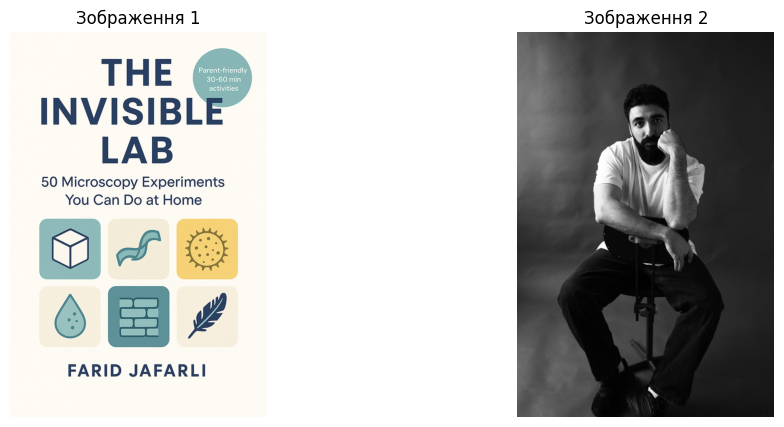

In [3]:
image1 = plt.imread('image1.jpg')
image2 = plt.imread('image2.jpg')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(image1)
axes[0].set_title('Зображення 1')
axes[0].axis('off')
axes[1].imshow(image2)
axes[1].set_title('Зображення 2')
axes[1].axis('off')
plt.show()

## 3. Визначення розміру зображення

In [4]:
print(f"Зображення 1 shape: {image1.shape}")
print(f"Зображення 2 shape: {image2.shape}")

Зображення 1 shape: (800, 534, 3)
Зображення 2 shape: (799, 533, 3)


## 4. Зміна форми зображення з 3D на 2D

In [5]:
height1, width1, channels1 = image1.shape
flat_image1 = image1.reshape(-1, width1 * channels1)

height2, width2, channels2 = image2.shape
flat_image2 = image2.reshape(-1, width2 * channels2)

print(f"Зображення 1: {image1.shape} -> {flat_image1.shape}")
print(f"Зображення 2: {image2.shape} -> {flat_image2.shape}")

Зображення 1: (800, 534, 3) -> (800, 1602)
Зображення 2: (799, 533, 3) -> (799, 1599)


## 5. SVD декомпозиція

In [6]:
U1, S1, Vt1 = np.linalg.svd(flat_image1.astype(float), full_matrices=False)
U2, S2, Vt2 = np.linalg.svd(flat_image2.astype(float), full_matrices=False)

print(f"Зображення 1 — U: {U1.shape}, S: {S1.shape}, Vt: {Vt1.shape}")
print(f"Зображення 2 — U: {U2.shape}, S: {S2.shape}, Vt: {Vt2.shape}")

Зображення 1 — U: (800, 800), S: (800,), Vt: (800, 1602)
Зображення 2 — U: (799, 799), S: (799,), Vt: (799, 1599)


## 6. Візуалізація перших k значень матриці Σ

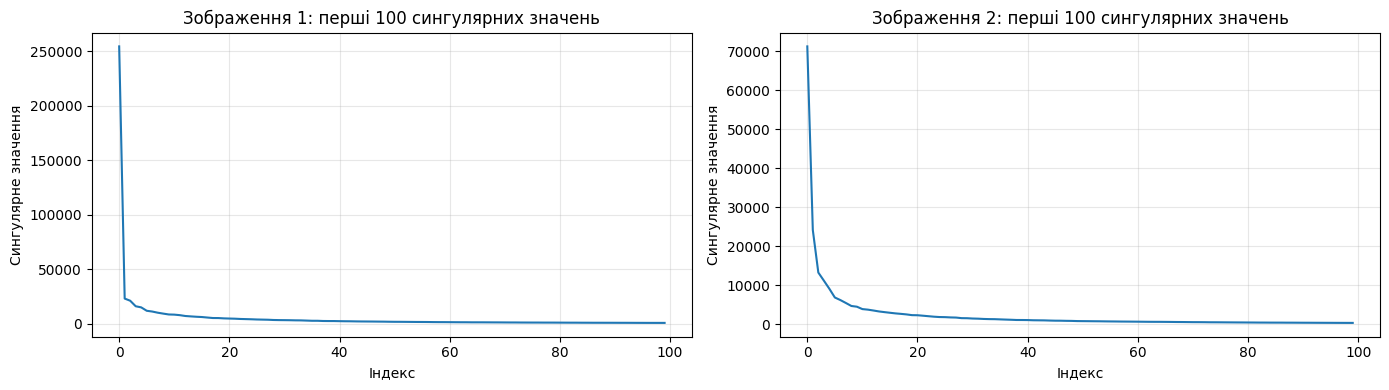

In [7]:
k = 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(np.arange(k), S1[:k])
axes[0].set_xlabel('Індекс')
axes[0].set_ylabel('Сингулярне значення')
axes[0].set_title(f'Зображення 1: перші {k} сингулярних значень')
axes[0].grid(True, alpha=0.3)

axes[1].plot(np.arange(k), S2[:k])
axes[1].set_xlabel('Індекс')
axes[1].set_ylabel('Сингулярне значення')
axes[1].set_title(f'Зображення 2: перші {k} сингулярних значень')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Стиснення зображення за допомогою TruncatedSVD

In [8]:
svd1 = TruncatedSVD(n_components=100)
truncated_image1 = svd1.fit_transform(flat_image1)

svd2 = TruncatedSVD(n_components=100)
truncated_image2 = svd2.fit_transform(flat_image2)

## 8. Помилка реконструкції (MSE)

In [9]:
reconstructed1 = svd1.inverse_transform(truncated_image1)
reconstructed2 = svd2.inverse_transform(truncated_image2)

error1 = np.mean(np.square(reconstructed1 - flat_image1))
error2 = np.mean(np.square(reconstructed2 - flat_image2))

print(f"MSE зображення 1: {error1}")
print(f"MSE зображення 2: {error2}")

MSE зображення 1: 42.73704000784046
MSE зображення 2: 4.9735878105510745


## 9. Візуалізація реконструйованого зображення

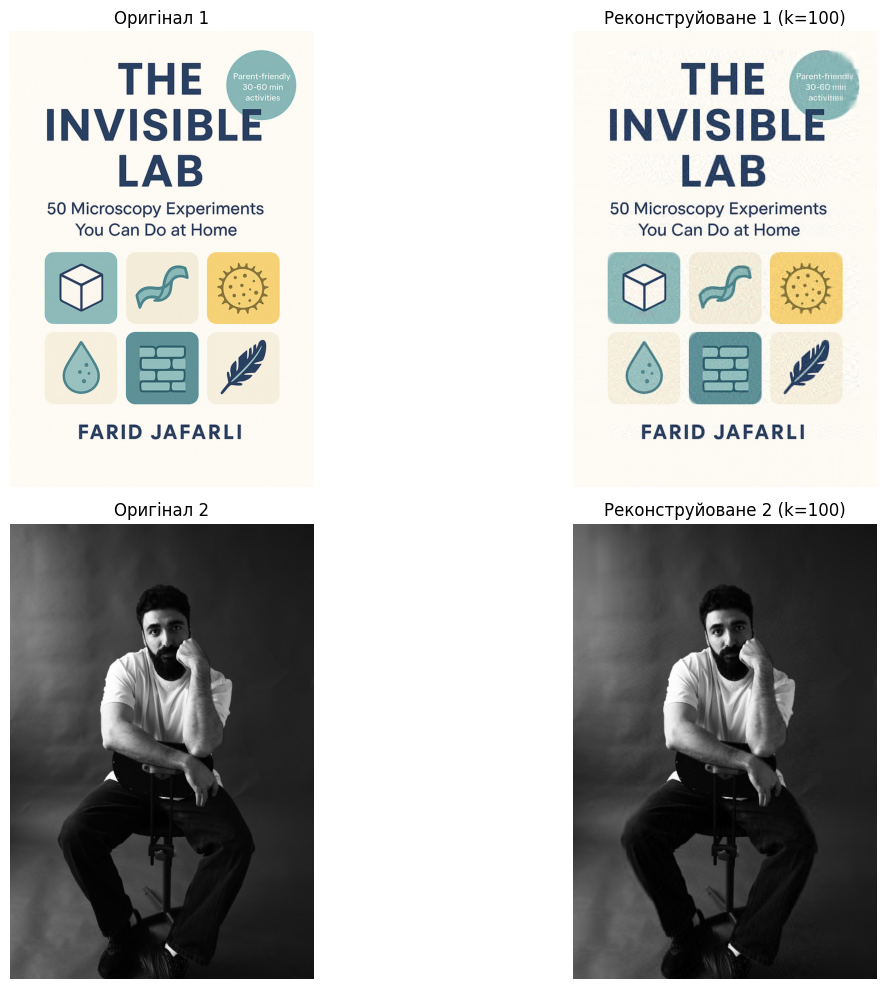

In [10]:
reconstructed1 = reconstructed1.reshape(height1, width1, channels1)
reconstructed1 = np.clip(reconstructed1, 0, 255).astype('uint8')

reconstructed2 = reconstructed2.reshape(height2, width2, channels2)
reconstructed2 = np.clip(reconstructed2, 0, 255).astype('uint8')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0][0].imshow(image1)
axes[0][0].set_title('Оригінал 1')
axes[0][0].axis('off')
axes[0][1].imshow(reconstructed1)
axes[0][1].set_title('Реконструйоване 1 (k=100)')
axes[0][1].axis('off')

axes[1][0].imshow(image2)
axes[1][0].set_title('Оригінал 2')
axes[1][0].axis('off')
axes[1][1].imshow(reconstructed2)
axes[1][1].set_title('Реконструйоване 2 (k=100)')
axes[1][1].axis('off')

plt.tight_layout()
plt.show()

## 10. Експерименти з різними значеннями k

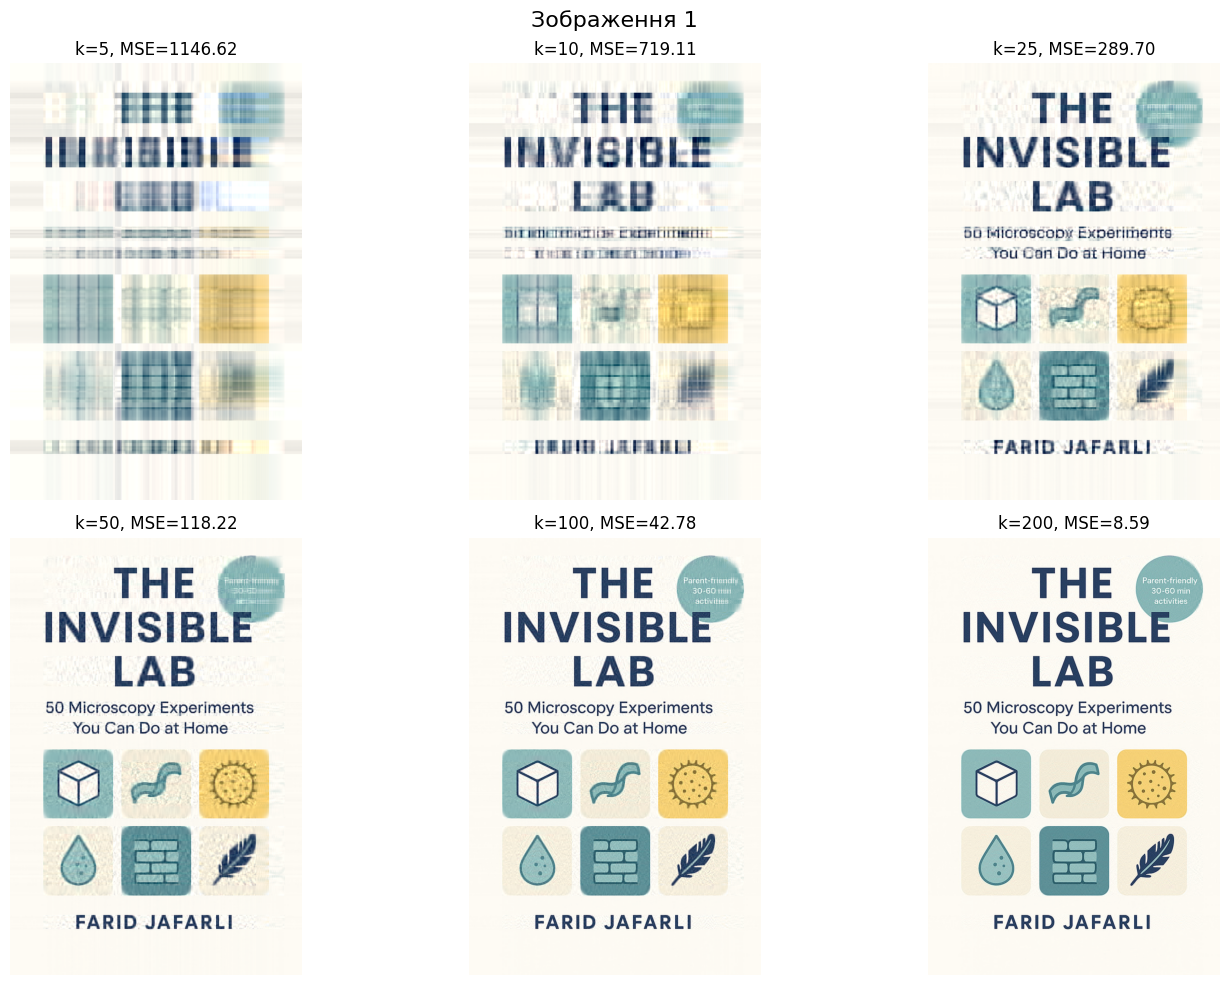

In [11]:
k_values = [5, 10, 25, 50, 100, 200]

# Зображення 1
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Зображення 1', fontsize=16)

for idx, k in enumerate(k_values):
    svd_k = TruncatedSVD(n_components=k)
    truncated = svd_k.fit_transform(flat_image1)
    reconstructed = svd_k.inverse_transform(truncated)

    mse = np.mean(np.square(reconstructed - flat_image1))

    reconstructed = reconstructed.reshape(height1, width1, channels1)
    reconstructed = np.clip(reconstructed, 0, 255).astype('uint8')

    ax = axes[idx // 3][idx % 3]
    ax.imshow(reconstructed)
    ax.set_title(f'k={k}, MSE={mse:.2f}')
    ax.axis('off')

plt.tight_layout()
plt.show()

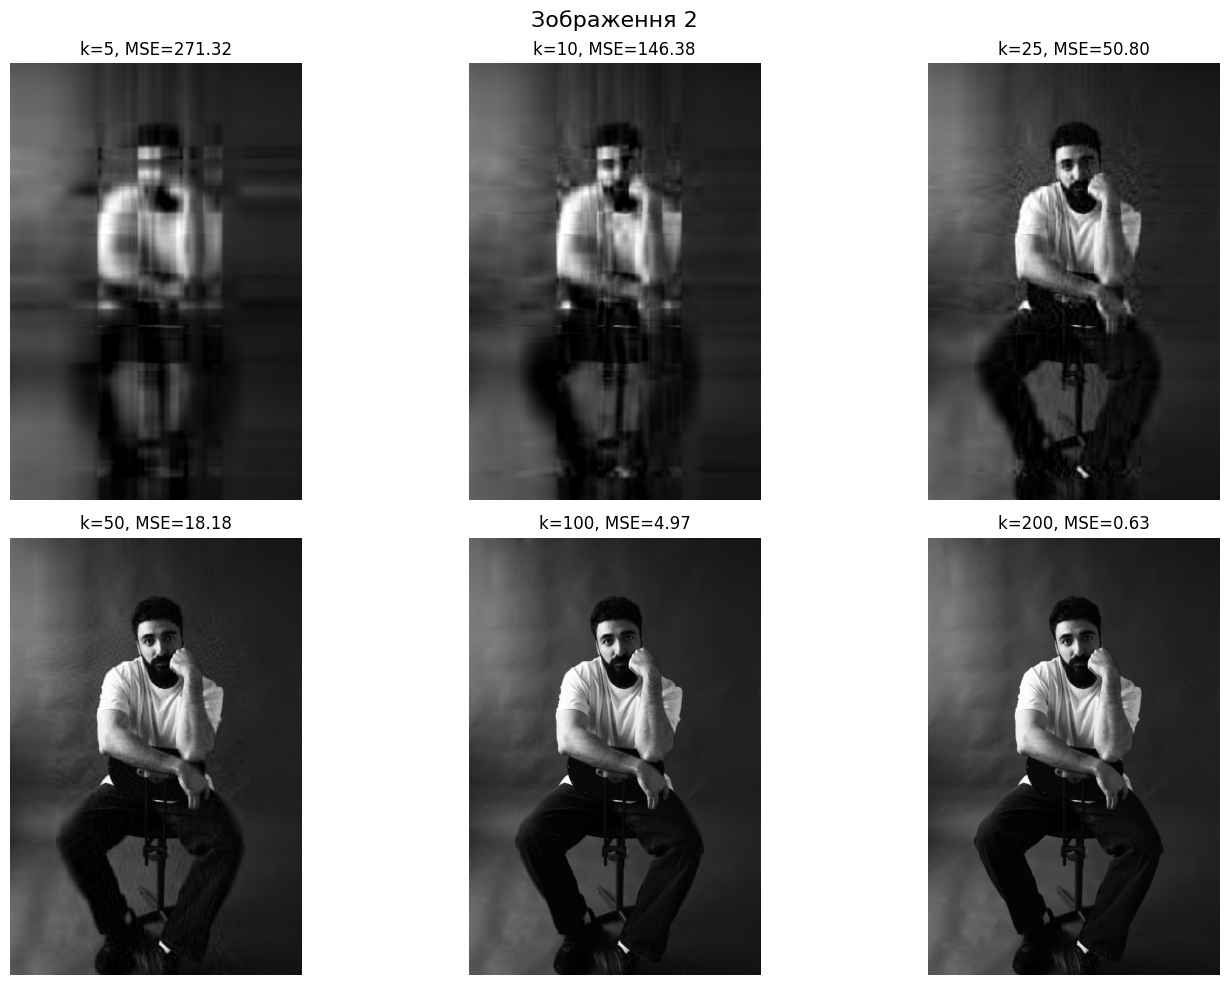

In [12]:
# Зображення 2
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Зображення 2', fontsize=16)

for idx, k in enumerate(k_values):
    svd_k = TruncatedSVD(n_components=k)
    truncated = svd_k.fit_transform(flat_image2)
    reconstructed = svd_k.inverse_transform(truncated)

    mse = np.mean(np.square(reconstructed - flat_image2))

    reconstructed = reconstructed.reshape(height2, width2, channels2)
    reconstructed = np.clip(reconstructed, 0, 255).astype('uint8')

    ax = axes[idx // 3][idx % 3]
    ax.imshow(reconstructed)
    ax.set_title(f'k={k}, MSE={mse:.2f}')
    ax.axis('off')

plt.tight_layout()
plt.show()

## Висновок

При малих значеннях k (5, 10) зображення значно втрачає деталі - помітні артефакти та розмиття. При k=25–50 основні контури та кольори зберігаються, але дрібні деталі втрачені. При k=100+ зображення візуально близьке до оригіналу, що підтверджується низьким значенням MSE. Це означає, що більшість інформації зосереджена в перших сингулярних значеннях, і SVD дозволяє ефективно стискати зображення.